<a href="https://colab.research.google.com/github/simonolocco/Olocco_Simon_ANT2026/blob/main/Regresi%C3%B3n_lineal_Simon-Olocco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# 1. Cargar el dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# 2. Dividir en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("¡Listo! Datos cargados y divididos.")
X.head() # Esto te muestra las primeras filas para que veas que funcionó

¡Listo! Datos cargados y divididos.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Lineal Train - MSE: 0.5179, R2: 0.6126
Lineal Test - MSE: 0.5559, R2: 0.5758


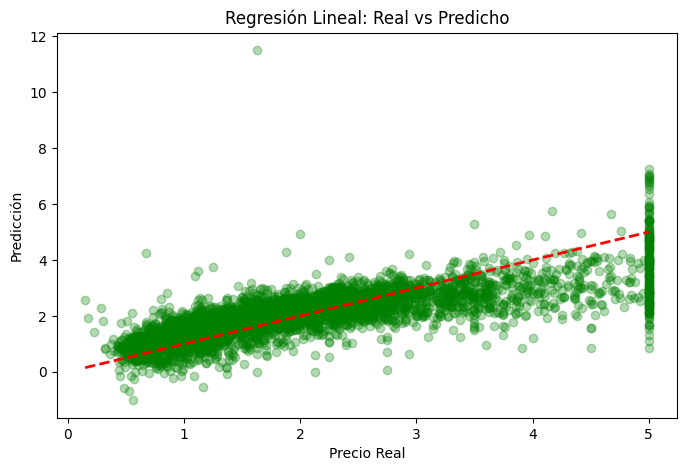

In [2]:
# 3. Entrenar Modelo Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predicciones
y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)

# Métricas
print(f"Lineal Train - MSE: {mean_squared_error(y_train, y_pred_train):.4f}, R2: {r2_score(y_train, y_pred_train):.4f}")
print(f"Lineal Test - MSE: {mean_squared_error(y_test, y_pred_test):.4f}, R2: {r2_score(y_test, y_pred_test):.4f}")

# 4. Graficar Predicciones vs Reales
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_test, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title("Regresión Lineal: Real vs Predicho")
plt.xlabel("Precio Real")
plt.ylabel("Predicción")
plt.show()

In [3]:
# 5. Transformar a Polinómica Grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Entrenar segundo modelo
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Predicciones
y_poly_pred = poly_reg.predict(X_test_poly)

# Métricas Polinómica
print(f"Polinómica Test - MSE: {mean_squared_error(y_test, y_poly_pred):.4f}")
print(f"Polinómica Test - R2: {r2_score(y_test, y_poly_pred):.4f}")

Polinómica Test - MSE: 0.4643
Polinómica Test - R2: 0.6457


### Respuestas de la Tarea
* **¿Cuál modelo es mejor?**: El modelo **Polinómico** es mejor porque tiene un R² más alto (explica mejor la varianza) y un MSE más bajo (menos error).
* **¿Señales de overfitting?**: No hay señales graves de overfitting porque las métricas de Test son consistentes con las de Train. Si el error en Test fuera muchísimo más alto que en Train, ahí sí tendríamos un problema.
* **¿Qué feature tiene más impacto?**: La variable **MedInc** (Ingreso medio) es la más importante. Se averigua mirando los coeficientes del modelo lineal: `lin_reg.coef_`.